#### Import libraries and load data

In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))

In [3]:
df_customer = pd.read_csv('dataset/customers.csv')
df_customer.head(2)
# df_customer.shape

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001


In [4]:
df_loans = pd.read_csv('dataset/loans.csv')
df_loans.head(2)
# df_loans.shape

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False


In [5]:
df_bureau = pd.read_csv('dataset/bureau_data.csv')
df_bureau.head(2)
# df_bureau.shape

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4


#### Merge data to form a single dataframe

In [6]:
df = pd.merge(df_customer,df_loans,on='cust_id')
df.head(2)
# df_customer.shape

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False


In [7]:
df_1 = pd.merge(df,df_bureau,on='cust_id')
df_1.head(2)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4


#### Split the data into train test dataset

In [8]:
from sklearn.model_selection import train_test_split\

X = df_1.drop('default',axis=1)
y = df.default

X_train , X_test , y_train , y_test = train_test_split(X,y,random_state=42,test_size=0.25)
df_train = pd.concat([X_train,y_train],axis=1)
df_test = pd.concat([X_test,y_test],axis=1)
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((37500, 32), (12500, 32), (37500,), (12500,))

##### For preventing data leakage we combine both X_train, y_train into a single dataset called df_train and same for test dataset also as df_test

In [9]:
df_train.isnull().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 48
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

#### handling missing values in residence_type using mode 

In [10]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [11]:
mode_residence = X_train.residence_type.mode()[0]
mode_residence

'Owned'

In [12]:
df_train.residence_type.fillna(mode_residence,inplace=True)

In [13]:
df_test.residence_type.fillna(mode_residence,inplace=True)

In [14]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [15]:
df_train.dtypes

cust_id                         object
age                              int64
gender                          object
marital_status                  object
employment_status               object
income                           int64
number_of_dependants             int64
residence_type                  object
years_at_current_address         int64
city                            object
state                           object
zipcode                          int64
loan_id                         object
loan_purpose                    object
loan_type                       object
sanction_amount                  int64
loan_amount                      int64
processing_fee                 float64
gst                              int64
net_disbursement                 int64
loan_tenure_months               int64
principal_outstanding            int64
bank_balance_at_application      int64
disbursal_date                  object
installment_start_dt            object
number_of_open_accounts  

#### take all the numerical column name into a variable

In [16]:
numerical_col = df_train.select_dtypes(include=['int64','float64']).columns
numerical_col

Index(['age', 'income', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio'],
      dtype='object')

#### take all the categorical column name into a variable

In [17]:
categorical_col = df_train.select_dtypes(include=['object']).columns
categorical_col

Index(['cust_id', 'gender', 'marital_status', 'employment_status',
       'residence_type', 'city', 'state', 'loan_id', 'loan_purpose',
       'loan_type', 'disbursal_date', 'installment_start_dt'],
      dtype='object')

In [18]:
df_train.head(2)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
27434,C27435,45,F,Single,Salaried,1131000,0,Owned,5,Ahmedabad,...,2022-04-21,2022-05-21,4,2,90,6,33,8,59,False
13400,C13401,29,M,Single,Salaried,2343000,0,Owned,25,Delhi,...,2020-11-24,2020-12-11,3,1,119,4,17,4,92,False


#### Plotting boxplot for every numerical columns to find any outliers are there in each column

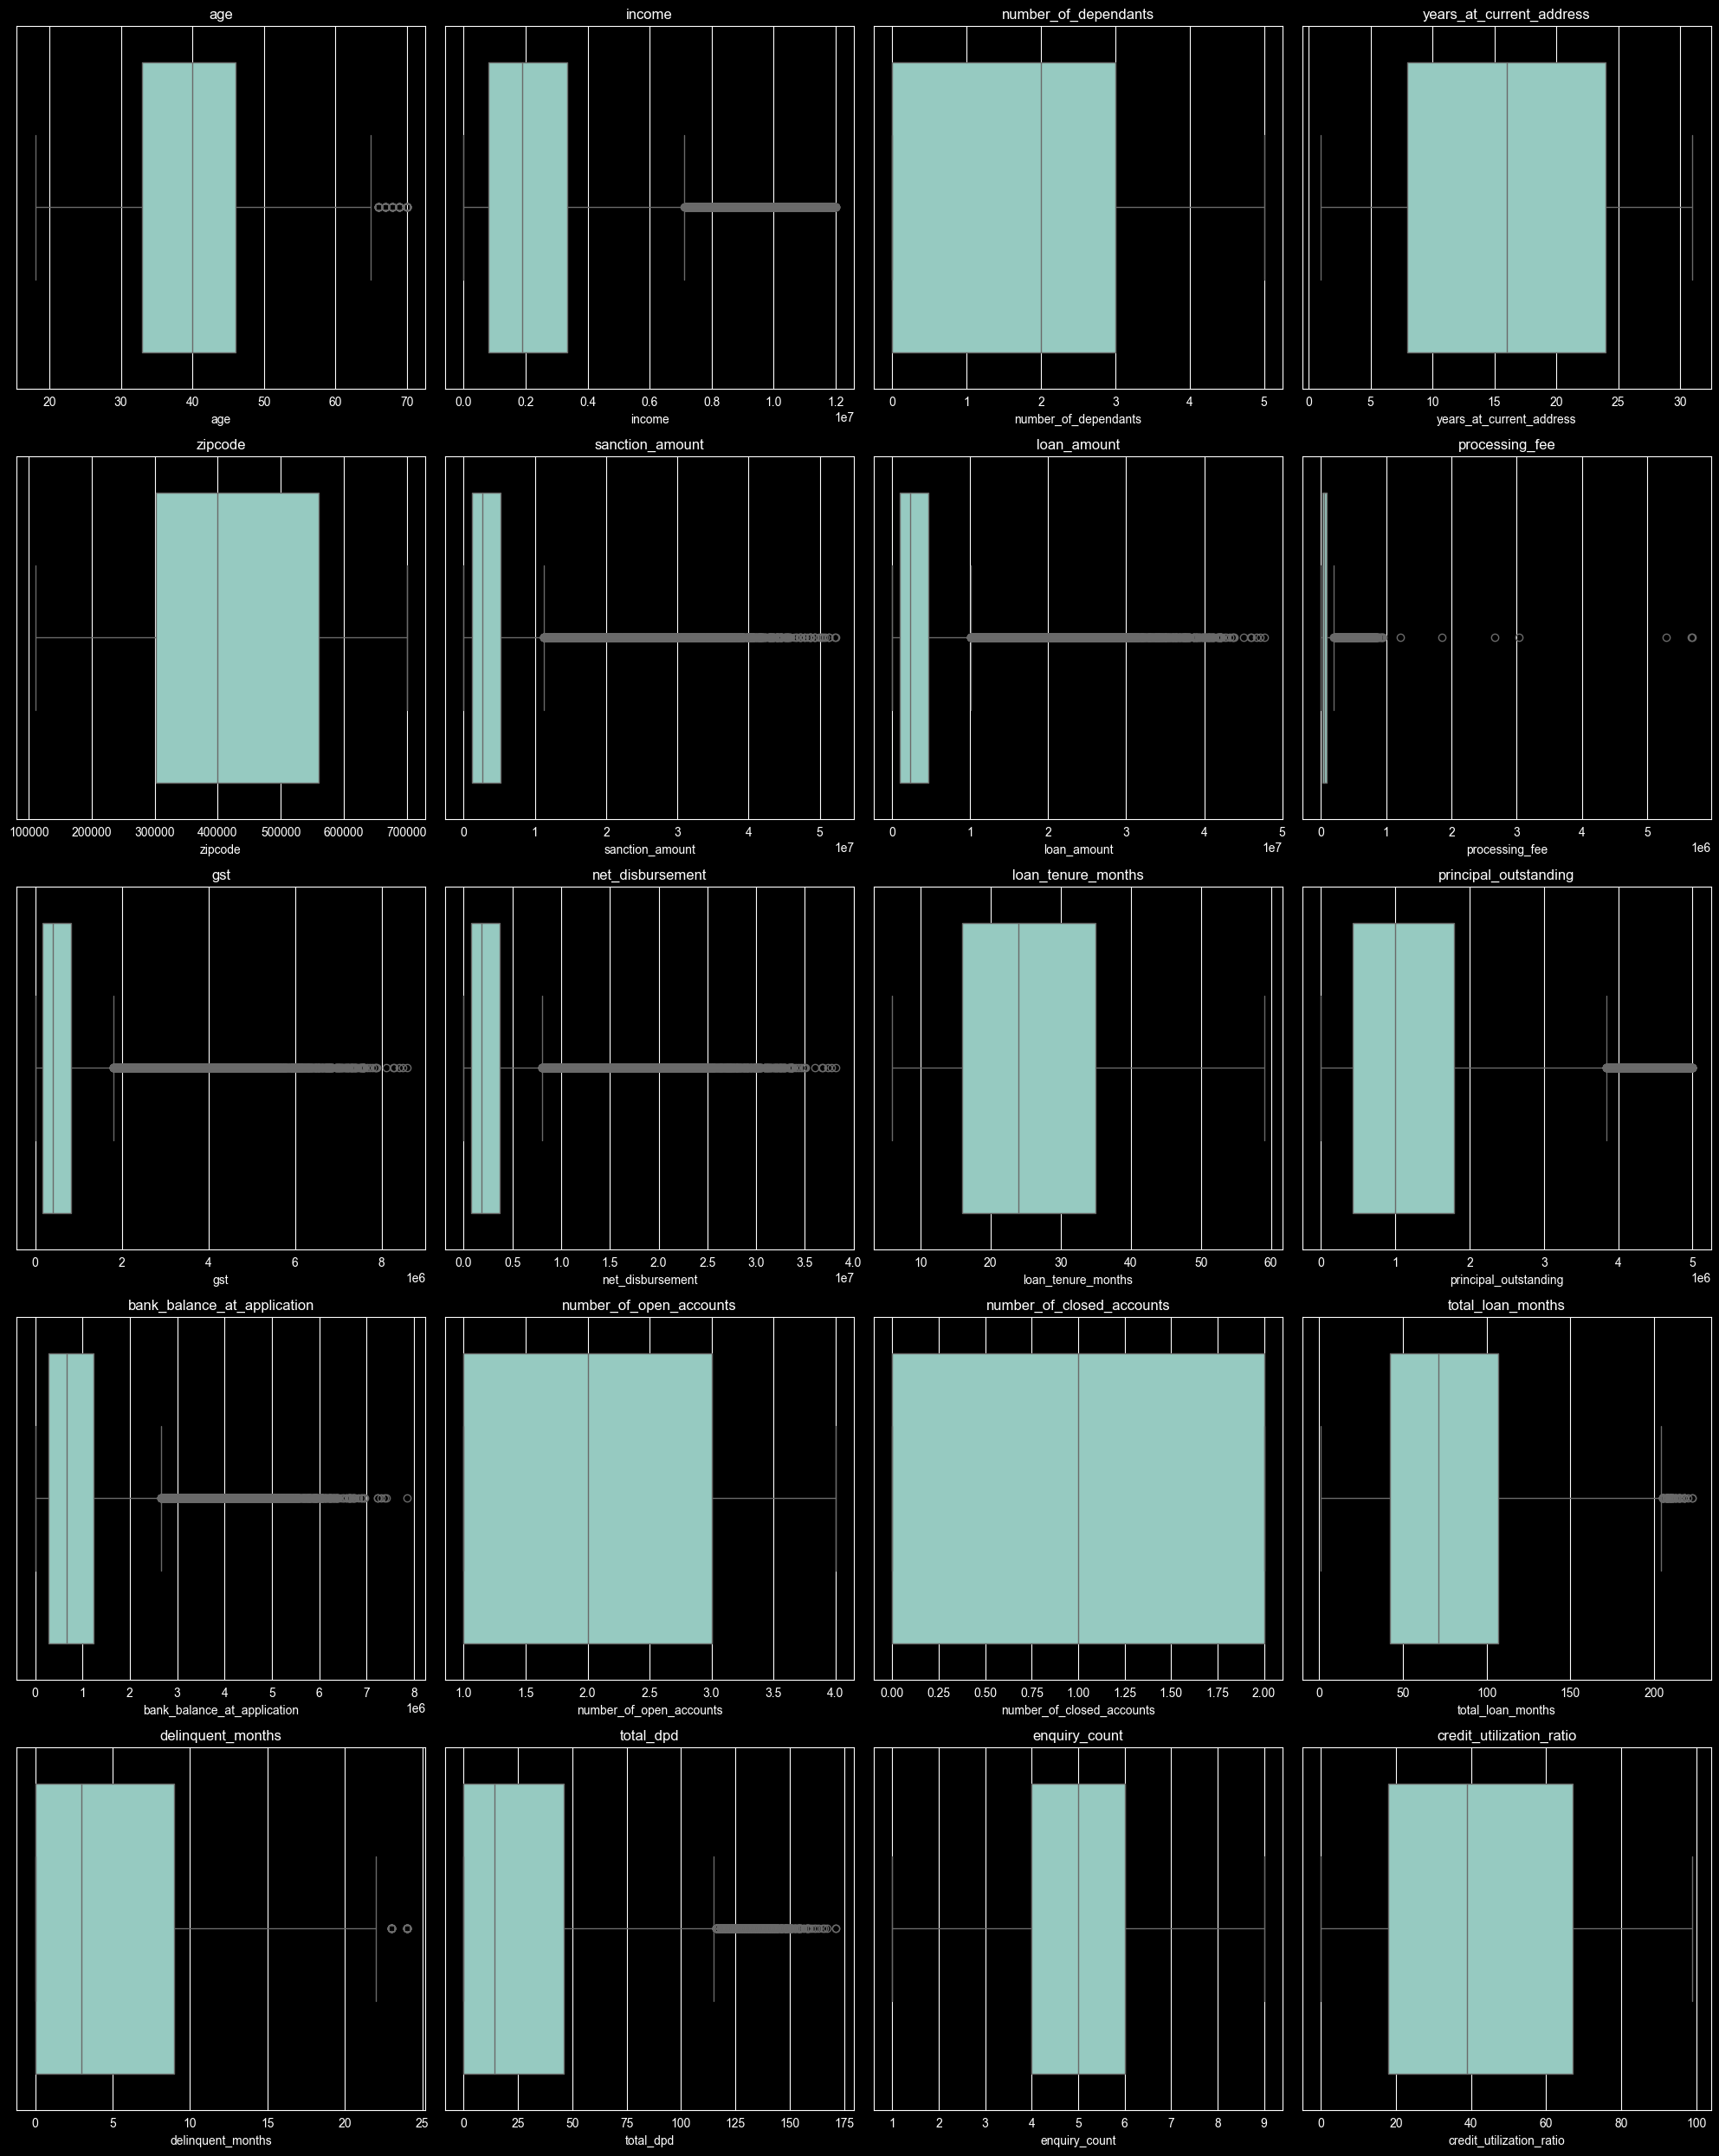

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

num_plots = len(numerical_col)
num_cols = 4  # Number of plots per row
num_rows = (num_plots + num_cols - 1) // num_cols  # Calculate the number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  # Adjust the figure size as needed
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, col in enumerate(numerical_col):
    sns.boxplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(col)  # Set the title to the name of the variable

# If there are any empty plots (if the number of plots isn't a perfect multiple of num_cols), hide the axes
for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

<div>
    <p>
       From the boxplot we finds out that the processing fess are having many outliers showing 50 lakhs PROCESSING FESS  for a loan of 4 lakh so we take a threshold like the 3 percentage of the loan amount. so i change outlier with 3 percentage of the loan amount  
    </p>
</div>

In [20]:
df_train.loc[
    df_train['processing_fee'] > df_train['loan_amount'],
    'processing_fee'
] = df_train['loan_amount']*0.03

#### Check for any errors in data

In [21]:
for col in categorical_col:
    print(f'{col} --> {df_train[col].unique()}')

cust_id --> ['C27435' 'C13401' 'C00884' ... 'C38159' 'C00861' 'C15796']
gender --> ['F' 'M']
marital_status --> ['Single' 'Married']
employment_status --> ['Salaried' 'Self-Employed']
residence_type --> ['Owned' 'Mortgage' 'Rented']
city --> ['Ahmedabad' 'Delhi' 'Lucknow' 'Bangalore' 'Jaipur' 'Hyderabad' 'Kolkata'
 'Pune' 'Chennai' 'Mumbai']
state --> ['Gujarat' 'Delhi' 'Uttar Pradesh' 'Karnataka' 'Rajasthan' 'Telangana'
 'West Bengal' 'Maharashtra' 'Tamil Nadu']
loan_id --> ['L27435' 'L13401' 'L00884' ... 'L38159' 'L00861' 'L15796']
loan_purpose --> ['Home' 'Auto' 'Personal' 'Education' 'Personaal']
loan_type --> ['Secured' 'Unsecured']
disbursal_date --> ['2022-04-21' '2020-11-24' '2019-08-25' ... '2024-04-06' '2021-11-30'
 '2021-11-24']
installment_start_dt --> ['2022-05-21' '2020-12-11' '2019-09-19' ... '2024-08-16' '2019-07-27'
 '2022-12-02']


In [22]:
df_train.loan_purpose.replace('Personaal','Personal',inplace=True)
df_test.loan_purpose.replace('Personaal','Personal',inplace=True)

df_train.loan_purpose.unique()
df_test.loan_purpose.unique()

array(['Education', 'Home', 'Auto', 'Personal'], dtype=object)

<h3 align='center' style='color:blue'>Exploratory Data Analysis</h3>

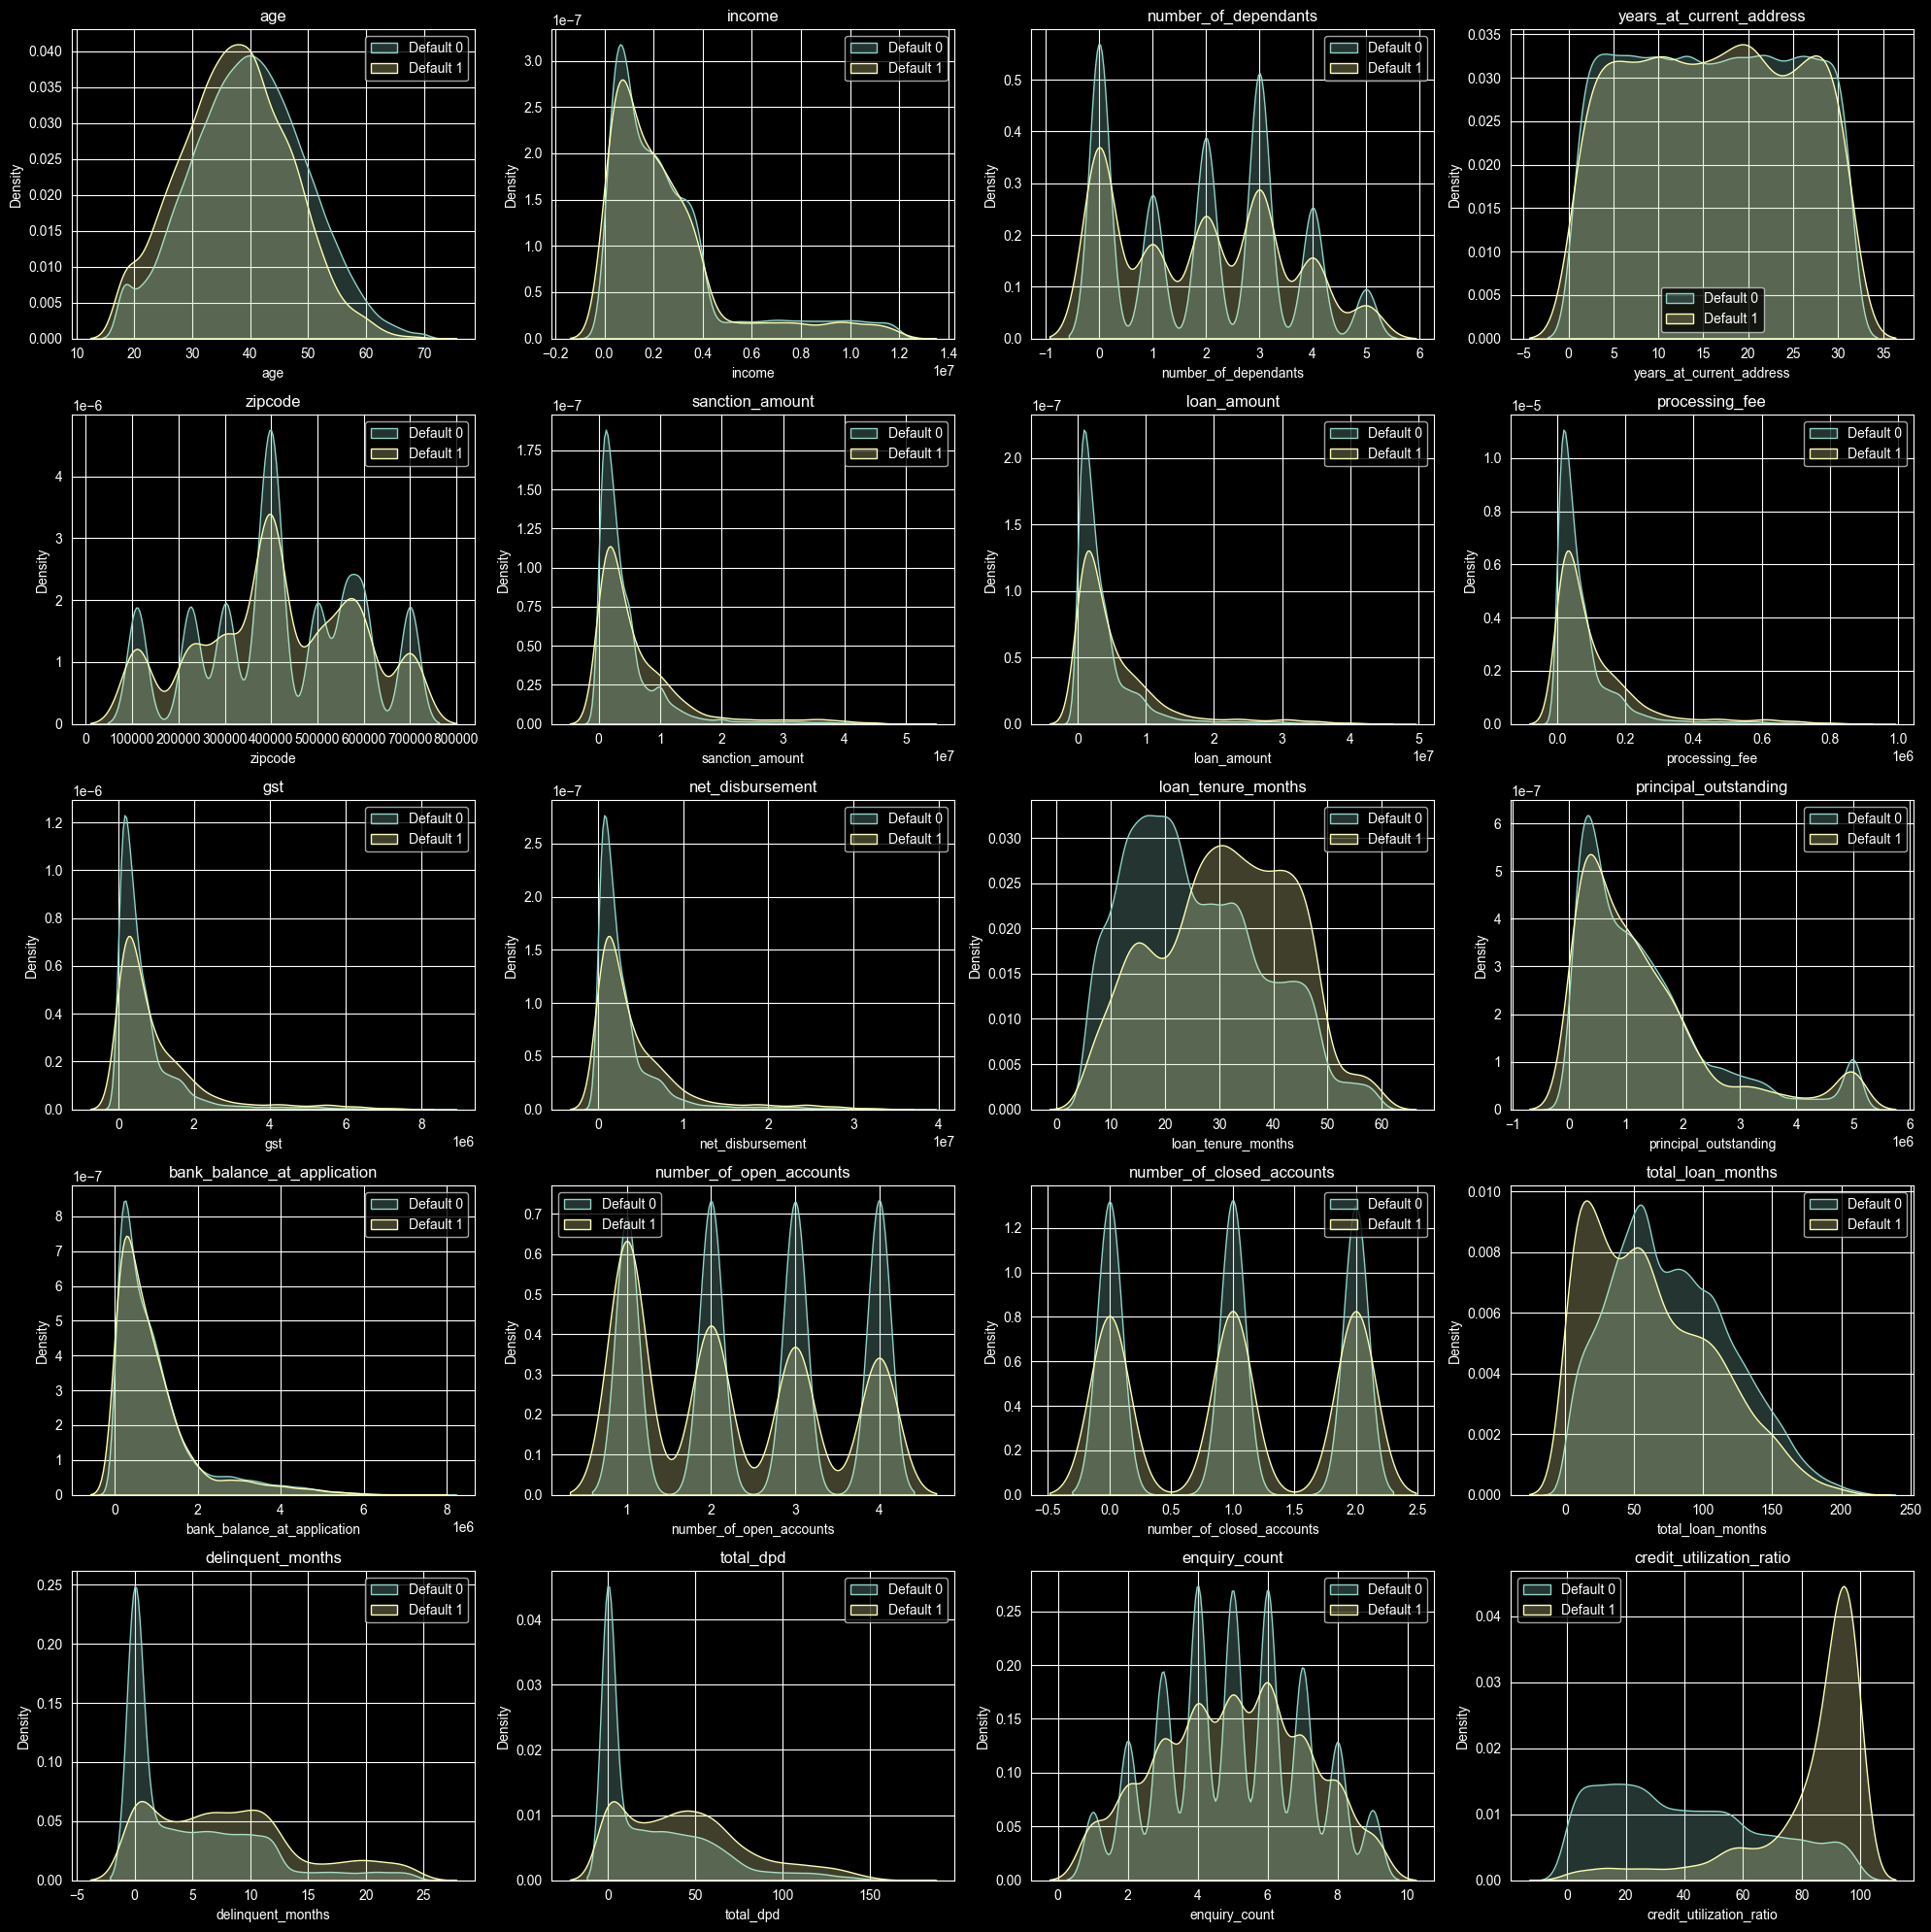

In [23]:
import math
num_cols = 4
num_rows = math.ceil(len(numerical_col) / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_col):
    ax = axes[i]
    
    sns.kdeplot(data=df_train[df_train['default'] == 0], x=col, ax=ax, label='Default 0',fill=True)
    sns.kdeplot(data=df_train[df_train['default'] == 1], x=col, ax=ax, label='Default 1',fill=True)
    
    ax.set_title(col)
    ax.legend()

# Hide extra plots
for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#### Insights

1. In the age column people with smaller age group tends to have set up default than people of older age group
2. people with default set up tends to have less deliquent months and total dpd
3. people with default set up have more credit utilization ratio than others

<h3 align='center' style='color:blue'>Feature Engineering</h3>

In [24]:
df_train[['loan_amount','income']]

,loan_amount,income
27434,3276000,1131000
13400,2540000,2343000
883,1920000,2891000
7303,298000,272000
45124,260000,141000
...,...,...
11284,4760000,3506000
44732,5302000,3889000
38158,6570000,2420000
860,3194000,2133000


In [25]:
df_train['loan_income_ratio'] = round(df_train['loan_amount']/df_train['income'],2)
df_test['loan_income_ratio'] = round(df_test['loan_amount']/df_test['income'],2)
df_train[['loan_amount','income','loan_income_ratio']]

,loan_amount,income,loan_income_ratio
27434,3276000,1131000,2.90
13400,2540000,2343000,1.08
883,1920000,2891000,0.66
7303,298000,272000,1.10
45124,260000,141000,1.84
...,...,...,...
11284,4760000,3506000,1.36
44732,5302000,3889000,1.36
38158,6570000,2420000,2.71
860,3194000,2133000,1.50


In [26]:
df_train.loan_income_ratio.fillna(df_train.loan_income_ratio.mean(),inplace=True)
df_test.loan_income_ratio.fillna(df_test.loan_income_ratio.mean(),inplace=True)
df_train.loan_income_ratio.isna().sum()

np.int64(0)

In [27]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_income_ratio'],
      dtype='object')

In [28]:
df_train[['total_loan_months','delinquent_months']]
df_train['deliquent_ratio'] = (df_train['delinquent_months']*100/df_train['total_loan_months']).round(2)
df_test['deliquent_ratio'] = (df_test['delinquent_months']*100/df_test['total_loan_months']).round(2)
df_train[['total_loan_months','delinquent_months','deliquent_ratio']].head(3)

,total_loan_months,delinquent_months,deliquent_ratio
27434,90,6,6.67
13400,119,4,3.36
883,83,14,16.87


In [29]:
df_train['avg_dpd_deliquency'] = np.where(df_train['delinquent_months'] !=0, df_train['total_dpd']/df_train['delinquent_months'].round(1),0)
df_test['avg_dpd_deliquency'] = np.where(df_test['delinquent_months'] !=0, df_test['total_dpd']/df_test['delinquent_months'].round(1),0)
df_train[['total_dpd','delinquent_months','avg_dpd_deliquency']].head(3)
df_train['avg_dpd_deliquency'].isna().sum()

np.int64(0)

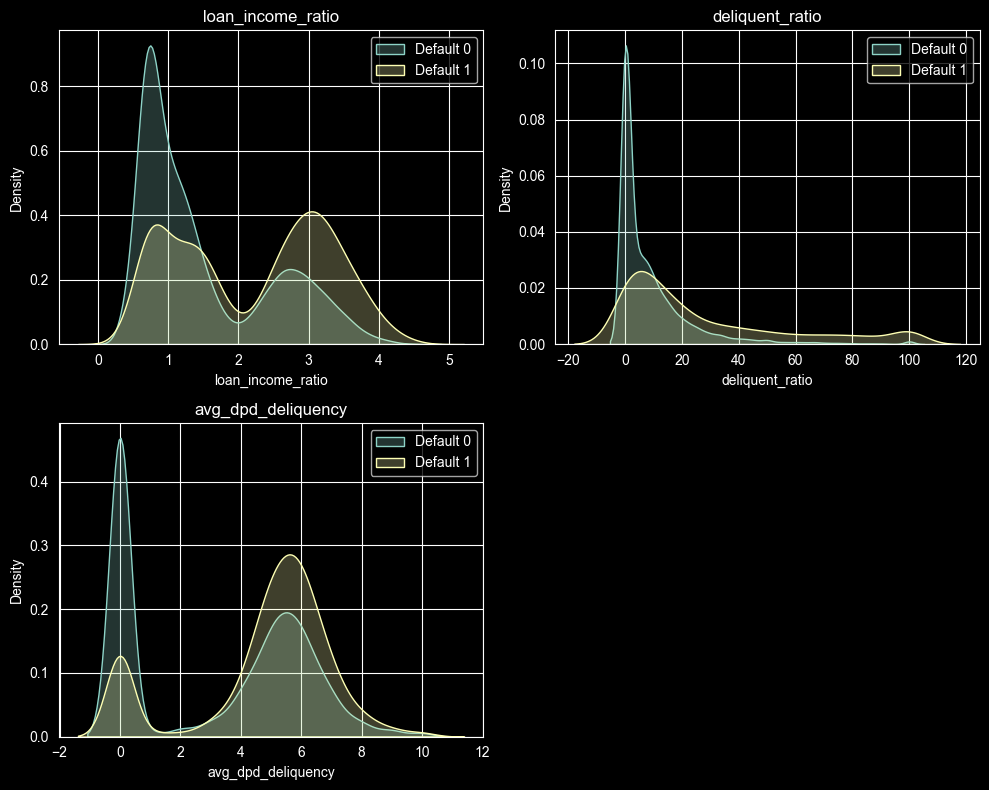

In [30]:
cols = ['loan_income_ratio','deliquent_ratio','avg_dpd_deliquency']

num_cols = 2
num_rows = math.ceil(len(cols) / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    
    sns.kdeplot(data=df_train[df_train['default'] == 0], x=col, ax=ax, label='Default 0',fill=True)
    sns.kdeplot(data=df_train[df_train['default'] == 1], x=col, ax=ax, label='Default 1',fill=True)
    
    ax.set_title(col)
    ax.legend()

# Hide extra plots
for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [31]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_income_ratio', 'deliquent_ratio', 'avg_dpd_deliquency'],
      dtype='object')

In [32]:
df_train.drop(['loan_id','cust_id'],axis=1,inplace=True)
df_train.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns",inplace=True)

In [33]:
df_test.drop(['loan_id','cust_id'],axis=1,inplace=True)
df_test.drop(['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis="columns",inplace=True)

In [34]:
# checking vif for multicollinearity

X_train = df_train.drop('default',axis=1)
y_train = df_train.default

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = X_train.select_dtypes(include=['int64','float64']).columns
scaler = MinMaxScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_income_ratio,deliquent_ratio,avg_dpd_deliquency
count,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00
mean,0.41,0.39,0.50,0.52,0.09,0.08,0.08,0.08,0.38,0.27,0.13,0.50,0.50,0.50,0.44,0.29,0.10,0.33
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.08,0.04,0.00,0.00,0.38,0.18,0.11,0.00,0.00
50%,0.42,0.40,0.50,0.49,0.05,0.05,0.05,0.05,0.34,0.20,0.08,0.33,0.50,0.50,0.39,0.20,0.04,0.43
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.36,0.16,0.67,1.00,0.62,0.68,0.50,0.13,0.58
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [35]:
X_test = df_test.drop('default',axis=1)
y_test = df_test.default

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_income_ratio,deliquent_ratio,avg_dpd_deliquency
count,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00
mean,0.41,0.39,0.50,0.53,0.09,0.08,0.08,0.08,0.38,0.27,0.13,0.50,0.51,0.50,0.44,0.29,0.10,0.33
std,0.19,0.31,0.30,0.29,0.12,0.11,0.11,0.11,0.24,0.24,0.13,0.37,0.41,0.26,0.30,0.23,0.17,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,0.33,0.02,0.02,0.02,0.02,0.19,0.09,0.04,0.00,0.00,0.38,0.18,0.11,0.00,0.00
50%,0.42,0.40,0.50,0.51,0.05,0.05,0.05,0.05,0.36,0.20,0.09,0.67,0.50,0.50,0.39,0.20,0.04,0.43
75%,0.54,0.60,0.77,0.76,0.10,0.10,0.10,0.10,0.55,0.36,0.16,1.00,1.00,0.75,0.68,0.50,0.13,0.58
max,1.00,1.00,1.00,1.00,0.95,1.00,1.00,1.00,1.00,1.00,0.88,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [36]:
X_train[cols_to_scale].isnull().sum()
# X_train[cols_to_scale].describe()

age                            0
number_of_dependants           0
years_at_current_address       0
zipcode                        0
sanction_amount                0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
number_of_open_accounts        0
number_of_closed_accounts      0
enquiry_count                  0
credit_utilization_ratio       0
loan_income_ratio              0
deliquent_ratio                0
avg_dpd_deliquency             0
dtype: int64

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [38]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement','principal_outstanding']

X_train_1 = X_train.drop(features_to_drop_vif, axis='columns')
numeric_columns = X_train_1.select_dtypes(['int64', 'float64']).columns

In [39]:
X_train_1.isna().sum()

age                            0
gender                         0
marital_status                 0
employment_status              0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
loan_purpose                   0
loan_type                      0
loan_tenure_months             0
bank_balance_at_application    0
number_of_open_accounts        0
number_of_closed_accounts      0
enquiry_count                  0
credit_utilization_ratio       0
loan_income_ratio              0
deliquent_ratio                0
avg_dpd_deliquency             0
dtype: int64

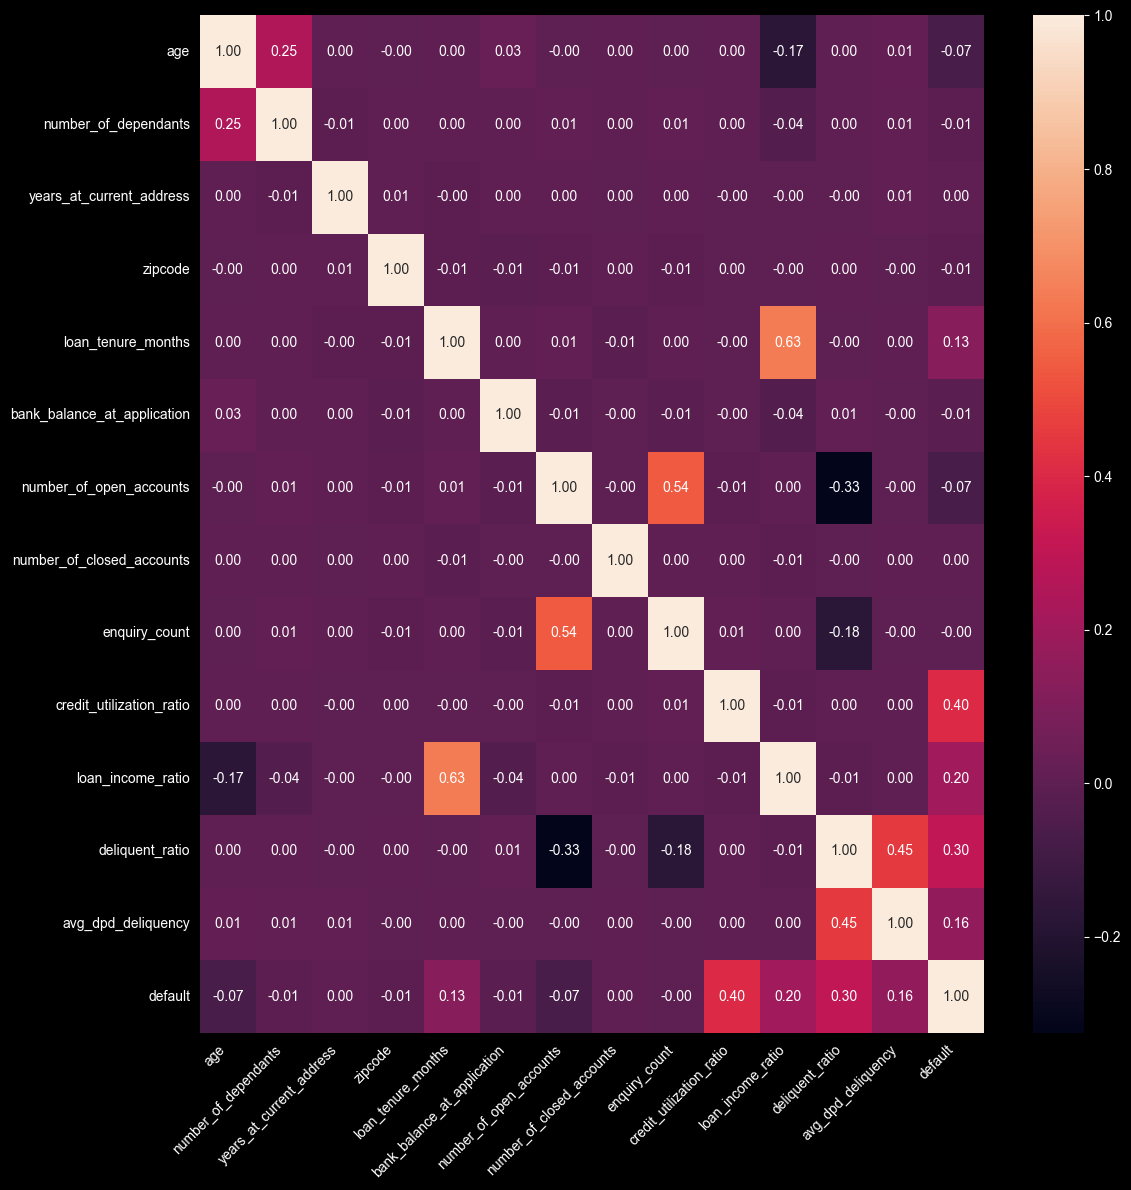

In [40]:
plt.figure(figsize=(12,12))
cm = df_train[numeric_columns.append(pd.Index(['default']))].corr()
sns.heatmap(cm, annot=True, fmt='0.2f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
categorical_col

Index(['cust_id', 'gender', 'marital_status', 'employment_status',
       'residence_type', 'city', 'state', 'loan_id', 'loan_purpose',
       'loan_type', 'disbursal_date', 'installment_start_dt'],
      dtype='object')

In [42]:
def calculate_woe_iv(data,feature,target):
    grouped = data.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count':'total','sum':'good'})
    grouped['bad'] = grouped['total'] - grouped['good']

    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    grouped['good_pct'] = round(grouped['good']/total_good,3)
    grouped['bad_pct'] = round(grouped['bad']/total_bad,3)
    grouped['woe'] = np.log(grouped['good_pct']/grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct']-grouped['bad_pct'])*grouped['woe']
    total_iv = grouped['iv'].sum()
    return grouped , total_iv


grouped , total_iv = calculate_woe_iv(pd.concat([X_train_1,y_train],axis=1),'loan_purpose','default')

grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,
Auto,7440,314,7126,0.10,0.21,-0.75,0.08
Education,5627,546,5081,0.17,0.15,0.14,0.00
Home,11274,1744,9530,0.55,0.28,0.68,0.18
Personal,13159,585,12574,0.18,0.37,-0.69,0.13


In [43]:
values_iv = {}

for feature in X_train_1.columns:
    if X_train_1[feature].dtype=='object':
        _,iv = calculate_woe_iv(pd.concat([X_train_1, y_train],axis=1), feature, 'default')
    else:
        X_binned = pd.cut(X_train_1[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_binned, y_train],axis=1), feature, 'default' )
    values_iv[feature] = iv

values_iv

{'age': np.float64(0.07745765214491576),
 'gender': np.float64(0.0005031560111616605),
 'marital_status': np.float64(0.0021296763356689428),
 'employment_status': np.float64(0.002482960644701658),
 'number_of_dependants': np.float64(0.003643682321205402),
 'residence_type': np.float64(0.2589884441240474),
 'years_at_current_address': np.float64(0.0010601045904638446),
 'city': np.float64(0.0008034433860711098),
 'state': np.float64(0.0007833427143641071),
 'zipcode': np.float64(0.0007230266648854944),
 'loan_purpose': np.float64(0.3950177279275702),
 'loan_type': np.float64(0.17325292973983816),
 'loan_tenure_months': np.float64(0.23453972983177462),
 'bank_balance_at_application': np.float64(0.004741463165409073),
 'number_of_open_accounts': np.float64(0.07387601465004427),
 'number_of_closed_accounts': np.float64(0.00025637678757219995),
 'enquiry_count': np.float64(0.0055572902214953),
 'credit_utilization_ratio': np.float64(2.4164913099502936),
 'loan_income_ratio': np.float64(0.49

In [44]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

iv_df = pd.DataFrame(list(values_iv.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.416
19,deliquent_ratio,0.684
18,loan_income_ratio,0.496
20,avg_dpd_deliquency,0.422
10,loan_purpose,0.395
5,residence_type,0.259
12,loan_tenure_months,0.235
11,loan_type,0.173
0,age,0.077
14,number_of_open_accounts,0.074


In [45]:
selected_features_iv = [feature for feature,iv in values_iv.items() if iv>0.02]
selected_features_iv

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_income_ratio',
 'deliquent_ratio',
 'avg_dpd_deliquency']

In [46]:
X_train_reduced = X_train_1[selected_features_iv]
X_test_reduced = X_test[selected_features_iv]

In [47]:
X_train_reduced.head(3)

,age,residence_type,loan_purpose,loan_type,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_income_ratio,deliquent_ratio,avg_dpd_deliquency
27434,0.519,Owned,Home,Secured,0.340,1.000,0.596,0.609,0.067,0.550
13400,0.212,Owned,Auto,Secured,0.509,0.667,0.929,0.183,0.034,0.425
883,0.615,Mortgage,Personal,Unsecured,0.245,0.333,0.838,0.084,0.169,0.557


In [48]:
X_train_encoded = pd.get_dummies(X_train_reduced,drop_first=True)
X_test_encoded = pd.get_dummies(X_test_reduced,drop_first=True)

In [49]:
X_train_encoded.isna().sum()

age                         0
loan_tenure_months          0
number_of_open_accounts     0
credit_utilization_ratio    0
loan_income_ratio           0
deliquent_ratio             0
avg_dpd_deliquency          0
residence_type_Owned        0
residence_type_Rented       0
loan_purpose_Education      0
loan_purpose_Home           0
loan_purpose_Personal       0
loan_type_Unsecured         0
dtype: int64

<h3 align='center' style='color:blue'>Model Training</h3>

In [50]:
X_test_encoded.isna().sum()

age                         0
loan_tenure_months          0
number_of_open_accounts     0
credit_utilization_ratio    0
loan_income_ratio           0
deliquent_ratio             0
avg_dpd_deliquency          0
residence_type_Owned        0
residence_type_Rented       0
loan_purpose_Education      0
loan_purpose_Home           0
loan_purpose_Personal       0
loan_type_Unsecured         0
dtype: int64

In [51]:
# Try training model with logistic regression , random forest , XGBoost

from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report

model_lr = LogisticRegression()
model_lr.fit(X_train_encoded,y_train)

y_pred = model_lr.predict(X_test_encoded)
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

       False       0.97      0.99      0.98     11392
        True       0.84      0.69      0.76      1108

    accuracy                           0.96     12500
   macro avg       0.91      0.84      0.87     12500
weighted avg       0.96      0.96      0.96     12500



In [52]:
from sklearn.ensemble import RandomForestClassifier

model_rb = RandomForestClassifier()
model_rb.fit(X_train_encoded,y_train)

y_pred = model_rb.predict(X_test_encoded)
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

       False       0.97      0.99      0.98     11392
        True       0.84      0.70      0.76      1108

    accuracy                           0.96     12500
   macro avg       0.90      0.84      0.87     12500
weighted avg       0.96      0.96      0.96     12500



In [53]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier()
model_xgb.fit(X_train_encoded,y_train)

y_pred = model_xgb.predict(X_test_encoded)
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

       False       0.98      0.98      0.98     11392
        True       0.83      0.75      0.78      1108

    accuracy                           0.96     12500
   macro avg       0.90      0.87      0.88     12500
weighted avg       0.96      0.96      0.96     12500



In [54]:
pip install -U imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [55]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)

X_train_smt , y_train_smt = smt.fit_resample(X_train_encoded,y_train)
y_train_smt.value_counts()

default
False    34233
True     34233
Name: count, dtype: int64

In [56]:
model_lr = LogisticRegression()
model_lr.fit(X_train_smt,y_train_smt)

y_pred = model_lr.predict(X_test_encoded)
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

       False       0.99      0.93      0.96     11392
        True       0.57      0.94      0.71      1108

    accuracy                           0.93     12500
   macro avg       0.78      0.94      0.83     12500
weighted avg       0.96      0.93      0.94     12500



In [57]:
model_xgb = XGBClassifier()
model_xgb.fit(X_train_smt,y_train_smt)

y_pred = model_xgb.predict(X_test_encoded)
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

       False       0.98      0.97      0.98     11392
        True       0.75      0.82      0.78      1108

    accuracy                           0.96     12500
   macro avg       0.86      0.90      0.88     12500
weighted avg       0.96      0.96      0.96     12500



In [58]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [59]:
import optuna
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

C:\Users\anilj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [60]:
def objective(trial):
    params={
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Logarithmically spaced values
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']),  # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Logarithmically spaced values for tolerance
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class weights
    }
    model_lgr = LogisticRegression(**params,max_iter=10000)
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model_lgr, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    return np.mean(scores)

In [61]:
study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50)
best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(X_train_encoded,y_train)

[I 2026-04-03 16:03:29,000] A new study created in memory with name: no-name-7c227a17-7f0b-4a0c-9f85-6b95e4d9c22e
[I 2026-04-03 16:03:31,922] Trial 0 finished with value: 0.8289900129327664 and parameters: {'C': 0.000125675395259672, 'solver': 'lbfgs', 'tol': 0.007829760066781256, 'class_weight': None}. Best is trial 0 with value: 0.8289900129327664.
[I 2026-04-03 16:03:34,775] Trial 1 finished with value: 0.9376105802694 and parameters: {'C': 0.04944351862348061, 'solver': 'saga', 'tol': 1.3168863930912468e-05, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9376105802694.
[I 2026-04-03 16:03:37,470] Trial 2 finished with value: 0.9448924465327346 and parameters: {'C': 8.729796437548373, 'solver': 'liblinear', 'tol': 0.00039477360401489204, 'class_weight': None}. Best is trial 2 with value: 0.9448924465327346.
[I 2026-04-03 16:03:40,063] Trial 3 finished with value: 0.8245253181180402 and parameters: {'C': 0.00011579846998406664, 'solver': 'lbfgs', 'tol': 0.0001715484611499

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",5.3545124810781495
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.00026405875844461274
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wi

<h3 align='center' style='color:blue'>Model Evaluation</h3>

In [62]:
from sklearn.metrics import roc_curve , auc

probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]
fpr , tpr , threshold = roc_curve(y_test,probabilities)

In [63]:
area = auc(fpr,tpr)
area

0.9830002940818561

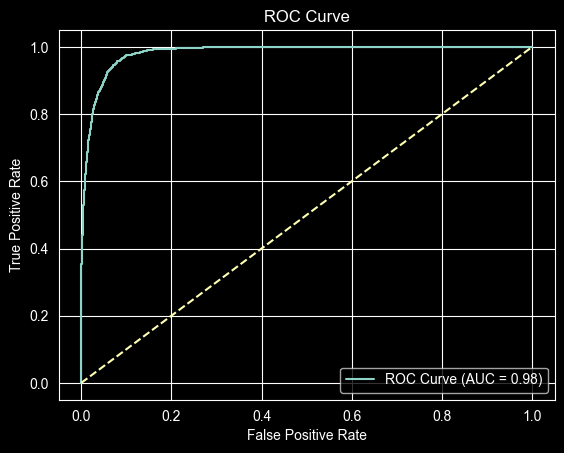

In [64]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {area:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

## Model Evaluation : Rankordering, KS statistic, Gini coeff

In [65]:
df_eval = pd.DataFrame({
    'Default_truth': y_test,
    'Default_probability': probabilities
})
df_eval.head()

,Default_truth,Default_probability
33553,False,0.000
9427,False,0.745
199,False,0.167
12447,False,0.462
39489,False,0.002


In [66]:
df_eval['Decile'] = pd.qcut(df_eval['Default_probability'],10,labels=False,duplicates='drop')
df_eval.head()

,Default_truth,Default_probability,Decile
33553,False,0.000,2
9427,False,0.745,8
199,False,0.167,7
12447,False,0.462,8
39489,False,0.002,4


In [67]:
df_eval.sort_values(by='Decile',ascending=False)
df_eval.head()

,Default_truth,Default_probability,Decile
33553,False,0.000,2
9427,False,0.745,8
199,False,0.167,7
12447,False,0.462,8
39489,False,0.002,4


In [68]:
df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({
    'Min_prob': x.Default_probability.min(),
    'Max_prob': x.Default_probability.max(),
    'Events': x.Default_truth.sum(),
    'Non_Event':  x.Default_truth.count() -  x.Default_truth.sum()
}),include_groups=False)
df_decile.reset_index(inplace=True)
df_decile.head()

,Decile,Min_prob,Max_prob,Events,Non_Event
0,0,0.000,0.000,0.000,1250.000
1,1,0.000,0.000,0.000,1250.000
2,2,0.000,0.000,0.000,1250.000
3,3,0.000,0.000,0.000,1250.000
4,4,0.000,0.002,0.000,1250.000


In [69]:
df_decile['Event_rate'] = df_decile['Events']*100/(df_decile['Events']+df_decile['Non_Event'])
df_decile['Non_Event_rate'] = df_decile['Non_Event']*100/(df_decile['Events']+df_decile['Non_Event'])

df_decile.head()

,Decile,Min_prob,Max_prob,Events,Non_Event,Event_rate,Non_Event_rate
0,0,0.000,0.000,0.000,1250.000,0.000,100.000
1,1,0.000,0.000,0.000,1250.000,0.000,100.000
2,2,0.000,0.000,0.000,1250.000,0.000,100.000
3,3,0.000,0.000,0.000,1250.000,0.000,100.000
4,4,0.000,0.002,0.000,1250.000,0.000,100.000


In [70]:
df_decile = df_decile.sort_values(by='Decile',ascending=False).reset_index(drop=True)
df_decile.head()

,Decile,Min_prob,Max_prob,Events,Non_Event,Event_rate,Non_Event_rate
0,9,0.822,1.000,915.000,335.000,73.200,26.800
1,8,0.257,0.822,173.000,1077.000,13.840,86.160
2,7,0.051,0.257,17.000,1233.000,1.360,98.640
3,6,0.010,0.051,2.000,1248.000,0.160,99.840
4,5,0.002,0.010,1.000,1249.000,0.080,99.920


In [71]:
df_decile['Cum_Event'] = df_decile['Events'].cumsum()
df_decile['Cum_Non_Event'] = df_decile['Non_Event'].cumsum()
df_decile.head()

,Decile,Min_prob,Max_prob,Events,Non_Event,Event_rate,Non_Event_rate,Cum_Event,Cum_Non_Event
0,9,0.822,1.000,915.000,335.000,73.200,26.800,915.000,335.000
1,8,0.257,0.822,173.000,1077.000,13.840,86.160,1088.000,1412.000
2,7,0.051,0.257,17.000,1233.000,1.360,98.640,1105.000,2645.000
3,6,0.010,0.051,2.000,1248.000,0.160,99.840,1107.000,3893.000
4,5,0.002,0.010,1.000,1249.000,0.080,99.920,1108.000,5142.000


In [72]:
df_decile['Cum_Event_Rate'] = df_decile['Cum_Event']*100/df_decile['Events'].sum()
df_decile['Cum_Non_Event_Rate'] = df_decile['Cum_Non_Event']*100/df_decile['Non_Event'].sum()
df_decile.head()

,Decile,Min_prob,Max_prob,Events,Non_Event,Event_rate,Non_Event_rate,Cum_Event,Cum_Non_Event,Cum_Event_Rate,Cum_Non_Event_Rate
0,9,0.822,1.000,915.000,335.000,73.200,26.800,915.000,335.000,82.581,2.941
1,8,0.257,0.822,173.000,1077.000,13.840,86.160,1088.000,1412.000,98.195,12.395
2,7,0.051,0.257,17.000,1233.000,1.360,98.640,1105.000,2645.000,99.729,23.218
3,6,0.010,0.051,2.000,1248.000,0.160,99.840,1107.000,3893.000,99.910,34.173
4,5,0.002,0.010,1.000,1249.000,0.080,99.920,1108.000,5142.000,100.000,45.137


In [73]:
df_decile['KS'] = abs(df_decile['Cum_Event_Rate'] - df_decile['Cum_Non_Event_Rate'])
df_decile

,Decile,Min_prob,Max_prob,Events,Non_Event,Event_rate,Non_Event_rate,Cum_Event,Cum_Non_Event,Cum_Event_Rate,Cum_Non_Event_Rate,KS
0,9,0.822,1.000,915.000,335.000,73.200,26.800,915.000,335.000,82.581,2.941,79.641
1,8,0.257,0.822,173.000,1077.000,13.840,86.160,1088.000,1412.000,98.195,12.395,85.800
2,7,0.051,0.257,17.000,1233.000,1.360,98.640,1105.000,2645.000,99.729,23.218,76.511
3,6,0.010,0.051,2.000,1248.000,0.160,99.840,1107.000,3893.000,99.910,34.173,65.737
4,5,0.002,0.010,1.000,1249.000,0.080,99.920,1108.000,5142.000,100.000,45.137,54.863
5,4,0.000,0.002,0.000,1250.000,0.000,100.000,1108.000,6392.000,100.000,56.110,43.890
6,3,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,7642.000,100.000,67.082,32.918
7,2,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,8892.000,100.000,78.055,21.945
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,10142.000,100.000,89.027,10.973
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1108.000,11392.000,100.000,100.000,0.000


In [74]:
gini_coefficient = 2 * area - 1

print("AUC:", area)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.9830002940818561
Gini Coefficient: 0.9660005881637121


In [75]:
final_model = best_model_logistic

In [76]:
from joblib import dump

model_data = {
    'model': final_model,
    'features': X_train_encoded.columns,
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}
dump(model_data, 'artifacts/model_data.joblib')

['artifacts/model_data.joblib']

In [77]:
X_test_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_income_ratio', 'deliquent_ratio',
       'avg_dpd_deliquency', 'residence_type_Owned', 'residence_type_Rented',
       'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Personal',
       'loan_type_Unsecured'],
      dtype='object')

In [78]:
cols_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_income_ratio', 'deliquent_ratio',
       'avg_dpd_deliquency'],
      dtype='object')